# Итоговый проект: Анализ музыкальных треков Spotify

**Цели проекта:**
1. Исследовать структуру музыкальных данных Spotify
2. Выделить группы схожих музыкальных композиций методом кластеризации (K-Means)
3. Выполнить снижение размерности методом главных компонент (PCA)
4. Построить модели классификации для определения жанра композиции
5. Сравнить качество различных алгоритмов машинного обучения


# 1. Описание набора данных

Набор данных содержит аудио-характеристики треков платформы **Spotify**, полученные через Spotify Web API.
Данные включают 114 000 треков, охватывающих 114 музыкальных жанров (по 1000 треков на жанр).

| Признак | Описание |
|---|---|
| `popularity` | Популярность трека (0–100) |
| `duration_ms` | Длительность трека в миллисекундах |
| `explicit` | Наличие нецензурного содержания |
| `danceability` | Танцевальность (0.0–1.0) |
| `energy` | Энергетика трека (0.0–1.0) |
| `key` | Тональность трека (0–11) |
| `loudness` | Громкость в децибелах (дБ) |
| `mode` | Лад (1 = мажор, 0 = минор) |
| `speechiness` | Доля речевых элементов (0.0–1.0) |
| `acousticness` | Акустичность (0.0–1.0) |
| `instrumentalness` | Доля инструментальных частей (0.0–1.0) |
| `liveness` | Вероятность живого исполнения (0.0–1.0) |
| `valence` | Музыкальная «позитивность» (0.0–1.0) |
| `tempo` | Темп в ударах в минуту (BPM) |
| `time_signature` | Размер такта |
| `track_genre` | Жанр (целевая переменная) |


# 2. Загрузка и предварительная обработка данных

## 2.1 Импорт библиотек

In [5]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
matplotlib.style.use('ggplot')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier




## 2.2 Загрузка данных

In [6]:
df = pd.read_csv("spotify.csv", sep=";")

# Убираем лишний индексный столбец
df.drop(columns=['Unnamed: 0'], inplace=True)

print(f"Размер датасета: {df.shape[0]} строк × {df.shape[1]} столбцов")
df.head()


Размер датасета: 114000 строк × 20 столбцов


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 2.3 Основные статистики

In [7]:
df.describe()


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## 2.4 Проверка пропущенных значений и дубликатов

In [8]:
print("Пропущенные значения по столбцам:")
print(df.isnull().sum())
print()
print(f"Дубликаты по (track_id, track_genre): {df.duplicated(subset=['track_id', 'track_genre']).sum()}")


Пропущенные значения по столбцам:
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Дубликаты по (track_id, track_genre): 450


In [9]:
# Удаляем строки с пропусками (их всего 3)
df.dropna(inplace=True)

# Удаляем дубликаты
df.drop_duplicates(subset=['track_id', 'track_genre'], inplace=True)

print(f"Размер после очистки: {df.shape[0]} строк × {df.shape[1]} столбцов")


Размер после очистки: 113549 строк × 20 столбцов


## 2.5 Визуализация распределения числовых признаков

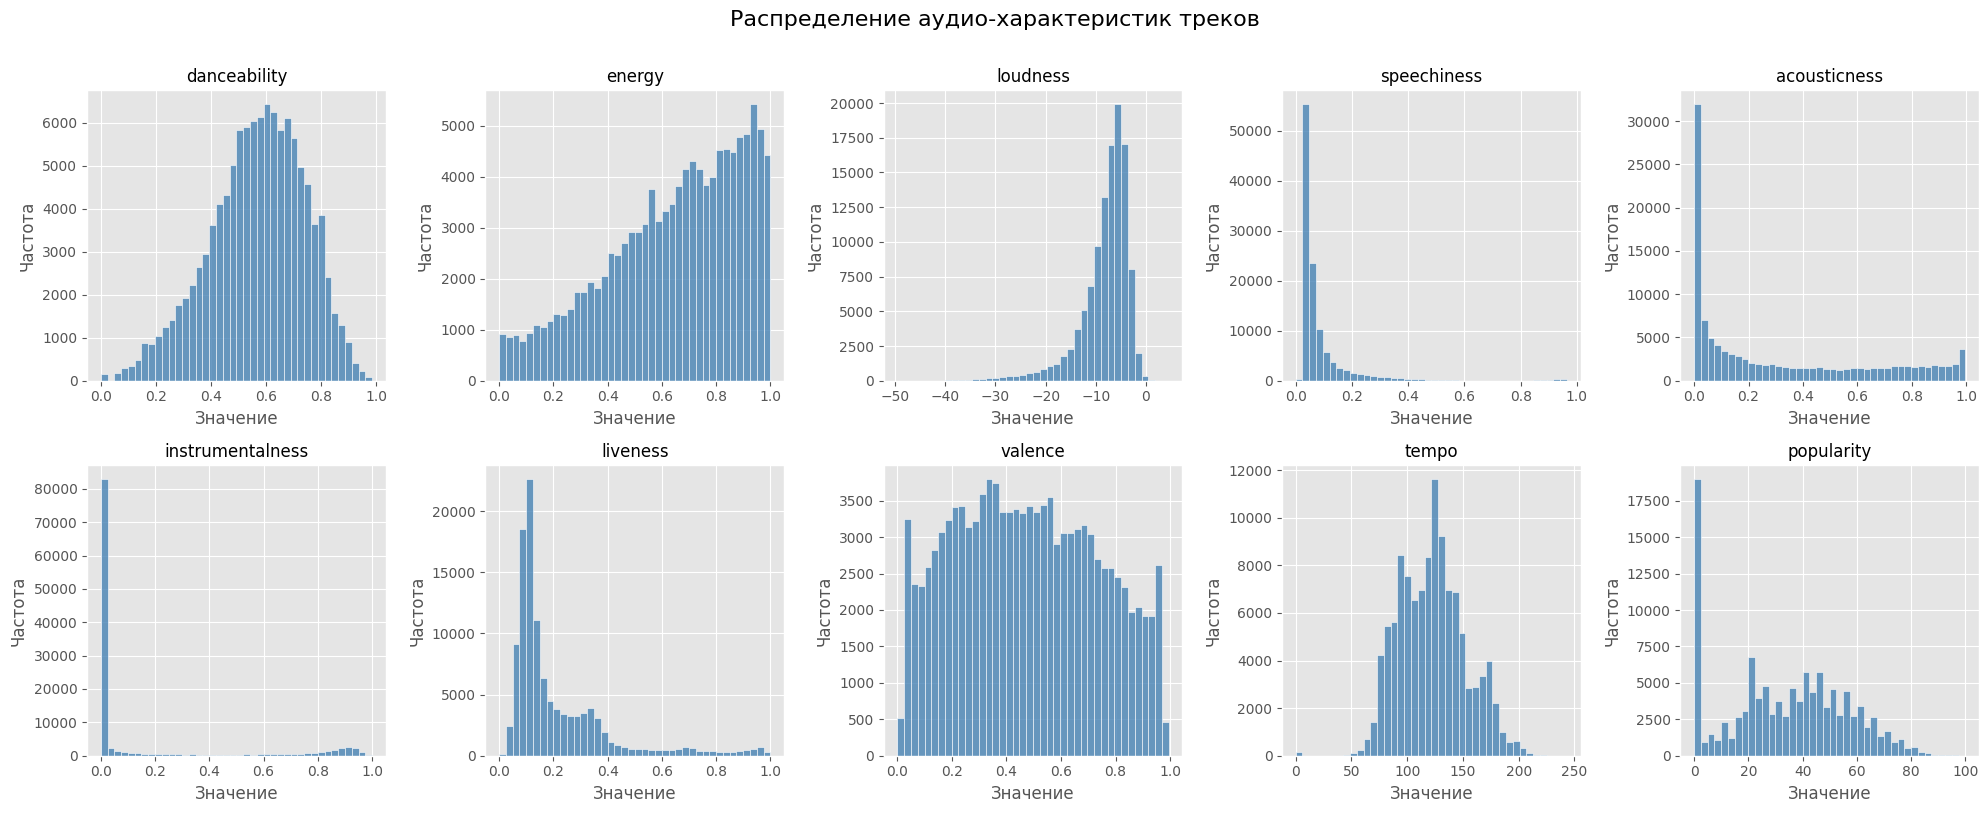

In [10]:
audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                   'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'popularity']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(audio_features):
    axes[i].hist(df[feat], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(feat, fontsize=12)
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Частота')

plt.suptitle('Распределение аудио-характеристик треков', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('01_distributions.png', dpi=120, bbox_inches='tight')
plt.show()



## 2.6 Матрица корреляций

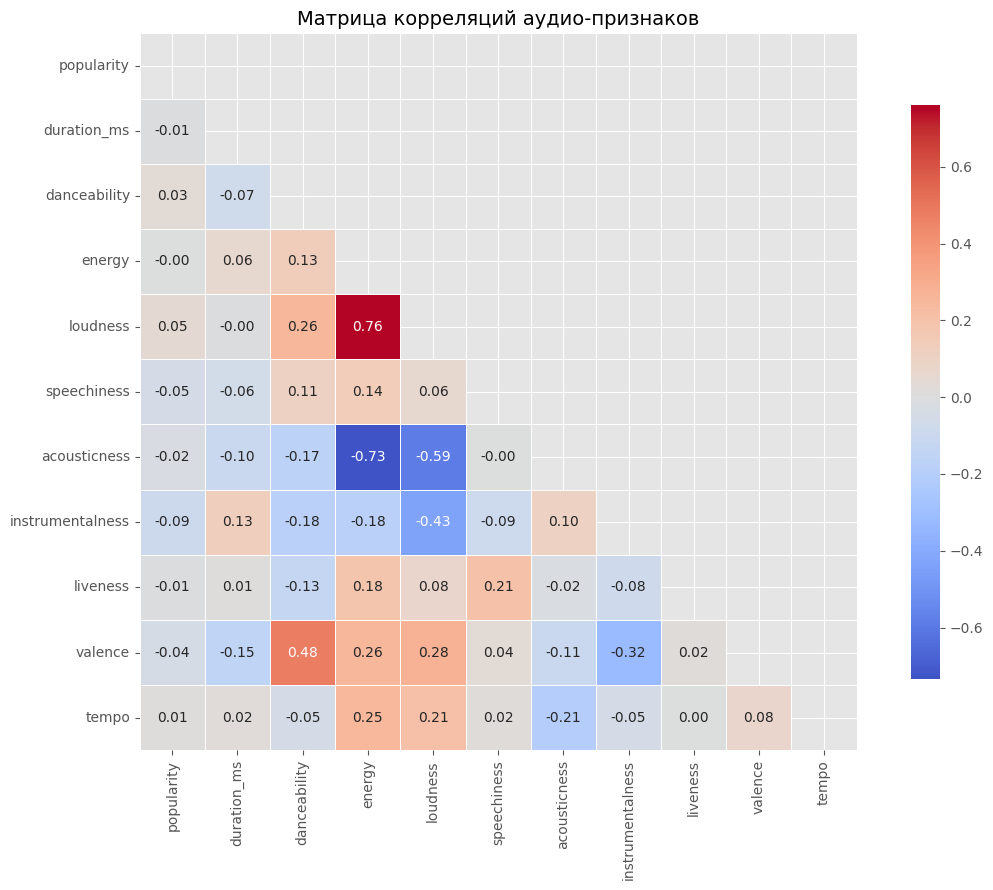

График сохранён: 02_correlation.png

Наиболее сильные корреляции:
   Признак 1    Признак 2  Корреляция  |Корреляция|
      energy     loudness    0.760624      0.760624
    loudness       energy    0.760624      0.760624
      energy acousticness   -0.732747      0.732747
acousticness       energy   -0.732747      0.732747
acousticness     loudness   -0.588111      0.588111
    loudness acousticness   -0.588111      0.588111
danceability      valence    0.476755      0.476755
     valence danceability    0.476755      0.476755


In [11]:
numeric_cols = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness',
                'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Матрица корреляций аудио-признаков', fontsize=14)
plt.tight_layout()
plt.savefig('02_correlation.png', dpi=120, bbox_inches='tight')
plt.show()
print("График сохранён: 02_correlation.png")
print()
print("Наиболее сильные корреляции:")
corr_pairs = corr.unstack().reset_index()
corr_pairs.columns = ['Признак 1', 'Признак 2', 'Корреляция']
corr_pairs = corr_pairs[corr_pairs['Признак 1'] != corr_pairs['Признак 2']]
corr_pairs['|Корреляция|'] = corr_pairs['Корреляция'].abs()
print(corr_pairs.sort_values('|Корреляция|', ascending=False).head(8).to_string(index=False))


## 2.7 Стандартизация признаков

In [12]:
feature_cols = ['danceability', 'energy', 'loudness', 'speechiness',
                'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
                'popularity', 'duration_ms', 'key', 'mode', 'time_signature']

X = df[feature_cols].copy()
y = df['track_genre'].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols, index=X.index)


print(f"Среднее по признакам: {X_scaled.mean().round(3).values}")
print(f"СКО по признакам:     {X_scaled.std().round(3).values}")


Среднее по признакам: [ 0.  0. -0.  0. -0.  0.  0. -0. -0. -0. -0.  0.  0. -0.]
СКО по признакам:     [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [13]:
feature_cols = ['danceability', 'energy', 'loudness', 'speechiness',
                'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
                'popularity', 'duration_ms', 'key', 'mode', 'time_signature']

X = df[feature_cols].copy()
y = df['track_genre'].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols, index=X.index)


print(f"Среднее по признакам: {X_scaled.mean().round(3).values}")
print(f"СКО по признакам:     {X_scaled.std().round(3).values}")


Среднее по признакам: [ 0.  0. -0.  0. -0.  0.  0. -0. -0. -0. -0.  0.  0. -0.]
СКО по признакам:     [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


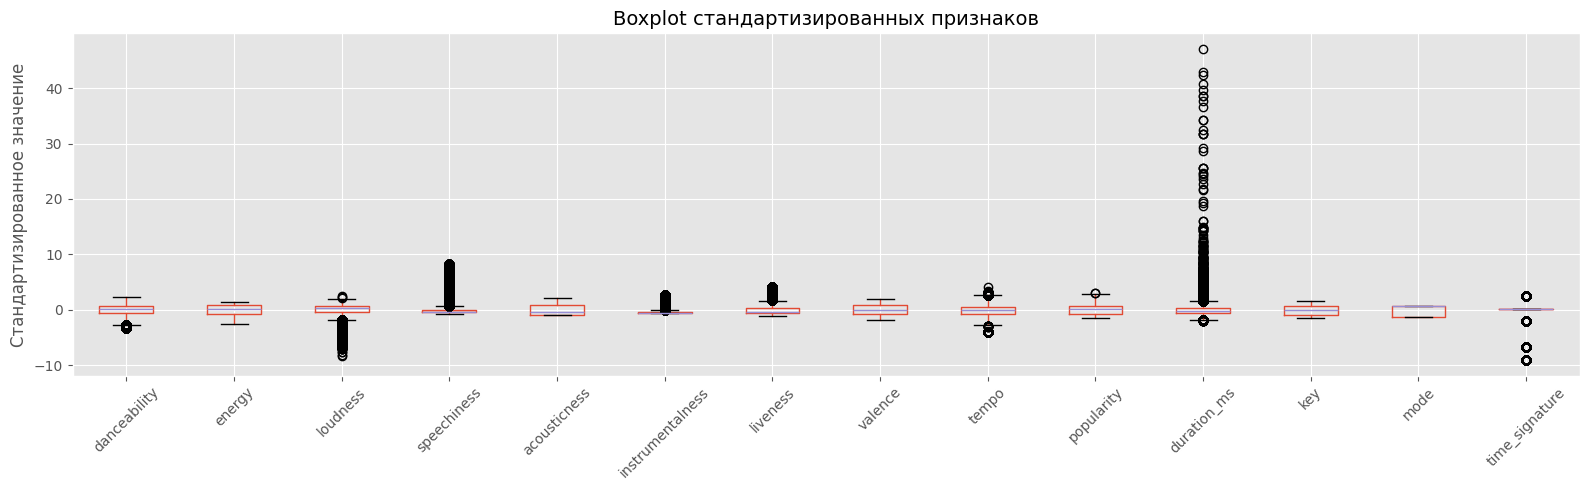

In [14]:
# Boxplot для проверки стандартизации
plt.figure(figsize=(16, 5))
X_scaled.boxplot(rot=45, fontsize=10)
plt.title('Boxplot стандартизированных признаков', fontsize=14)
plt.ylabel('Стандартизированное значение')
plt.tight_layout()
plt.savefig('03_boxplot_scaled.png', dpi=120, bbox_inches='tight')
plt.show()



# 3. Снижение размерности (PCA)

Метод главных компонент (PCA) позволяет снизить размерность пространства признаков,
сохраняя максимальную долю дисперсии данных.


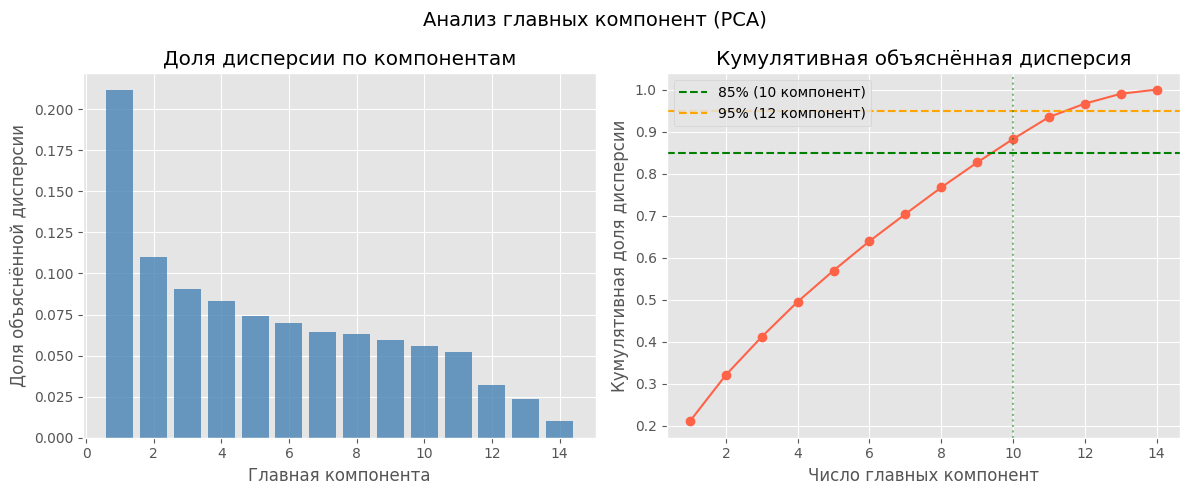

Для объяснения 85% дисперсии достаточно 10 компонент (из 14)
Для объяснения 95% дисперсии достаточно 12 компонент (из 14)


In [15]:
pca_full = PCA(n_components=len(feature_cols))
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Определяем минимальное число компонент для 85% дисперсии
n_85 = np.argmax(cumulative >= 0.85) + 1
n_95 = np.argmax(cumulative >= 0.95) + 1

plt.figure(figsize=(12, 5))

# Доля объясненной дисперсии
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained)+1), explained, color='steelblue', alpha=0.8)
plt.xlabel('Главная компонента')
plt.ylabel('Доля объяснённой дисперсии')
plt.title('Доля дисперсии по компонентам')

# Кумулятивная дисперсия
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative)+1), cumulative, marker='o', color='tomato')
plt.axhline(y=0.85, color='green', linestyle='--', label=f'85% ({n_85} компонент)')
plt.axhline(y=0.95, color='orange', linestyle='--', label=f'95% ({n_95} компонент)')
plt.axvline(x=n_85, color='green', linestyle=':', alpha=0.5)
plt.xlabel('Число главных компонент')
plt.ylabel('Кумулятивная доля дисперсии')
plt.title('Кумулятивная объяснённая дисперсия')
plt.legend()

plt.suptitle('Анализ главных компонент (PCA)', fontsize=14)
plt.tight_layout()
plt.savefig('04_pca_variance.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Для объяснения 85% дисперсии достаточно {n_85} компонент (из {len(feature_cols)})")
print(f"Для объяснения 95% дисперсии достаточно {n_95} компонент (из {len(feature_cols)})")


In [16]:
# Применяем PCA с 2 компонентами для визуализации
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Применяем PCA с n_85 компонент для моделирования
pca_nd = PCA(n_components=n_85)
X_pca = pca_nd.fit_transform(X_scaled)

print(f"PCA 2D: объясняет {pca_2d.explained_variance_ratio_.sum()*100:.1f}% дисперсии")
print(f"PCA {n_85}D: объясняет {pca_nd.explained_variance_ratio_.sum()*100:.1f}% дисперсии")

# Нагрузки на признаки
loadings = pd.DataFrame(
    pca_full.components_[:2].T,
    index=feature_cols,
    columns=['PC1', 'PC2']
)
print("\nНагрузки первых двух главных компонент:")
print(loadings.sort_values('PC1', ascending=False))


PCA 2D: объясняет 32.1% дисперсии
PCA 10D: объясняет 88.2% дисперсии

Нагрузки первых двух главных компонент:
                       PC1       PC2
loudness          0.503502 -0.082080
energy            0.495277 -0.271979
valence           0.290588  0.479225
danceability      0.252870  0.474719
time_signature    0.199581  0.083393
tempo             0.182254 -0.232985
speechiness       0.094270  0.067851
liveness          0.074706 -0.151725
key               0.049171 -0.021224
popularity        0.030155  0.029306
duration_ms      -0.010909 -0.395659
mode             -0.058400  0.109175
instrumentalness -0.271775 -0.321113
acousticness     -0.429612  0.320198


# 4. Кластеризация (K-Means)

Выделим группы схожих треков методом K-Means.
Используем метод «каменистой осыпи» (elbow method) для выбора оптимального числа кластеров.


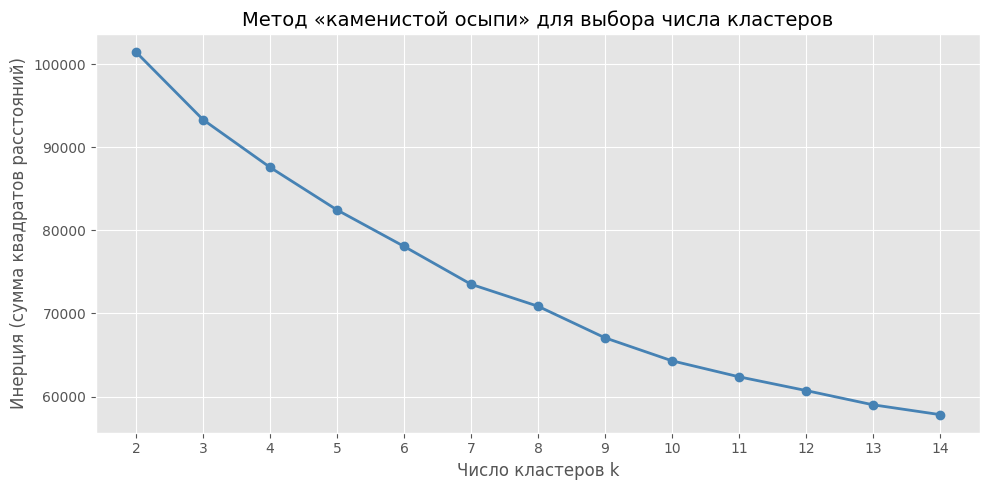

In [17]:
# Для кластеризации берём подвыборку (для скорости)
np.random.seed(42)
sample_idx = np.random.choice(len(X_pca), size=10000, replace=False)
X_cluster = X_pca[sample_idx]

K_range = range(2, 15)
inertias = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(list(K_range), inertias, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Число кластеров k', fontsize=12)
plt.ylabel('Инерция (сумма квадратов расстояний)', fontsize=12)
plt.title('Метод «каменистой осыпи» для выбора числа кластеров', fontsize=14)
plt.xticks(list(K_range))
plt.tight_layout()
plt.savefig('05_elbow.png', dpi=120, bbox_inches='tight')
plt.show()



In [18]:
# Выбираем k=6 (излом на графике)
OPTIMAL_K = 6

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=20, max_iter=500)
km_final.fit(X_pca)
cluster_labels = km_final.labels_

df_cluster = df.copy()
df_cluster['cluster'] = cluster_labels

print(f"Кластеризация выполнена: k={OPTIMAL_K} кластеров")
print("Размеры кластеров:")
print(df_cluster['cluster'].value_counts().sort_index())


Кластеризация выполнена: k=6 кластеров
Размеры кластеров:
cluster
0     7241
1    31680
2    19816
3     8075
4    21715
5    25022
Name: count, dtype: int64


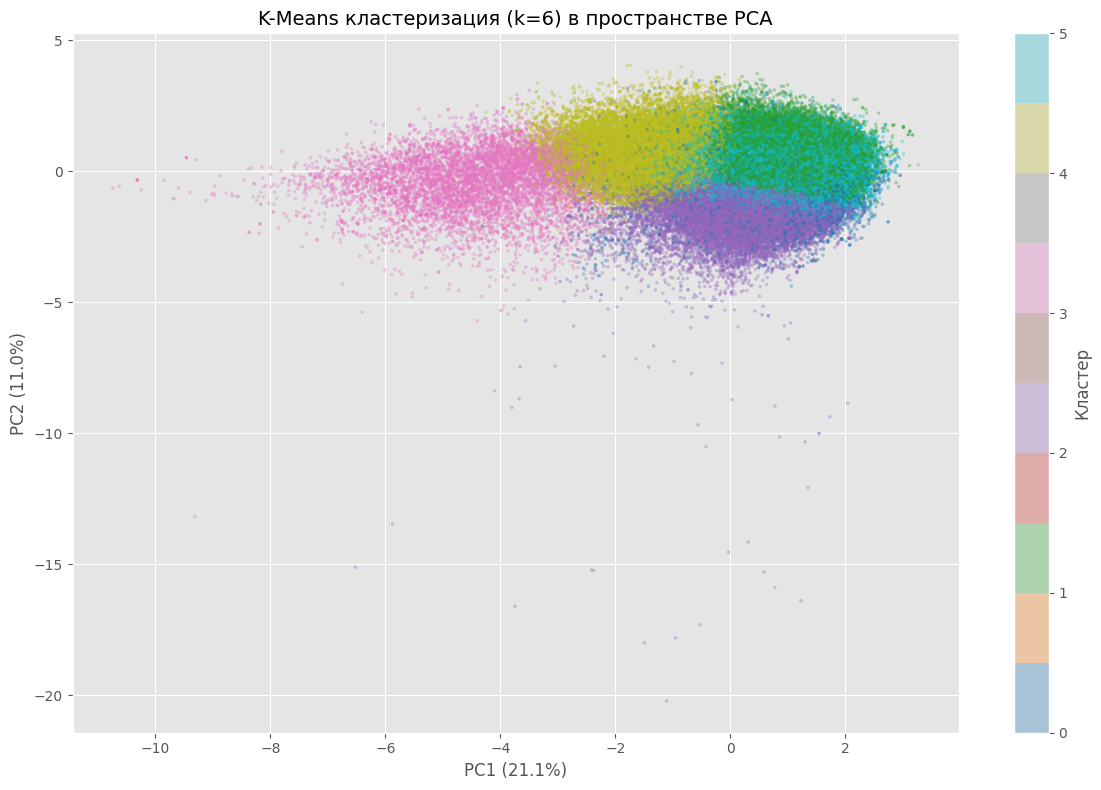

In [20]:
# Визуализация кластеров в пространстве первых двух главных компонент
X_pca_2d_all = pca_2d.transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca_2d_all[:, 0], X_pca_2d_all[:, 1],
                      c=cluster_labels, cmap='tab10', alpha=0.3, s=4)
plt.colorbar(scatter, label='Кластер')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.title(f'K-Means кластеризация (k={OPTIMAL_K}) в пространстве PCA', fontsize=14)
plt.tight_layout()
plt.savefig('06_clusters_pca.png', dpi=120, bbox_inches='tight')
plt.show()



Средние значения признаков по кластерам:
         danceability  energy  loudness  speechiness  acousticness  \
cluster                                                              
0               0.519   0.749    -7.532        0.230         0.368   
1               0.648   0.750    -6.000        0.082         0.176   
2               0.456   0.802    -6.624        0.078         0.061   
3               0.340   0.175   -20.510        0.051         0.859   
4               0.546   0.376   -10.835        0.052         0.682   
5               0.659   0.730    -6.364        0.092         0.178   

         instrumentalness  liveness  valence    tempo  
cluster                                                
0                   0.038     0.740    0.488  120.159  
1                   0.031     0.178    0.638  123.606  
2                   0.369     0.196    0.256  137.985  
3                   0.705     0.164    0.171  102.583  
4                   0.074     0.165    0.425  114.412  
5     

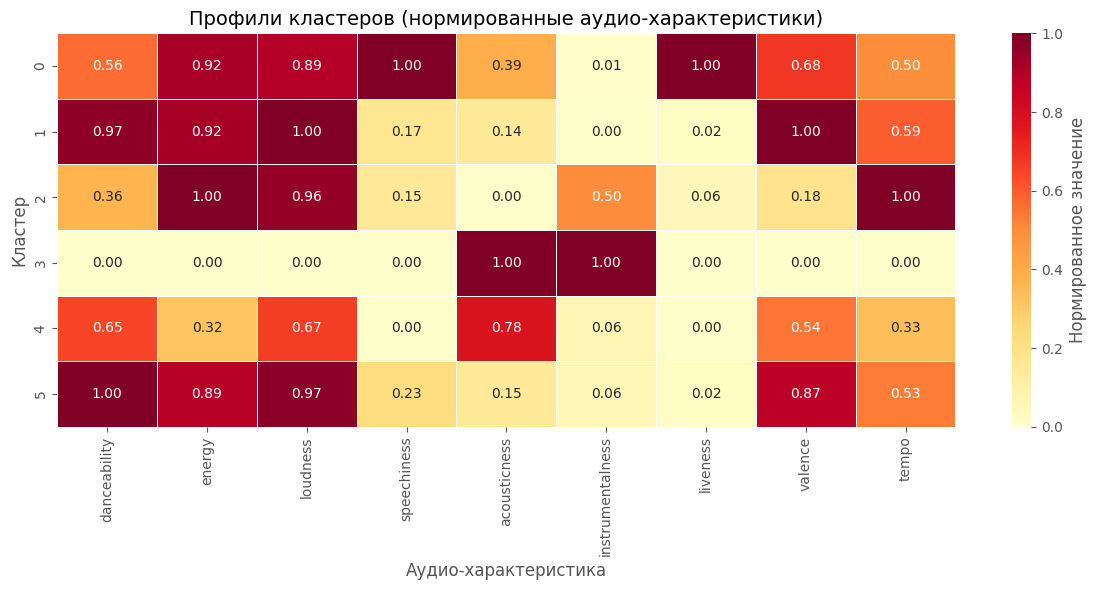

In [21]:
# Профили кластеров по аудио-характеристикам
cluster_profile_cols = ['danceability', 'energy', 'loudness', 'speechiness',
                         'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

cluster_profile = df_cluster.groupby('cluster')[cluster_profile_cols].mean()
print("Средние значения признаков по кластерам:")
print(cluster_profile.round(3))

# Тепловая карта профилей
plt.figure(figsize=(12, 6))
profile_scaled = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())
sns.heatmap(profile_scaled, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Нормированное значение'})
plt.title('Профили кластеров (нормированные аудио-характеристики)', fontsize=14)
plt.xlabel('Аудио-характеристика')
plt.ylabel('Кластер')
plt.tight_layout()
plt.savefig('07_cluster_profiles.png', dpi=120, bbox_inches='tight')
plt.show()



In [ ]:
# Топ жанры в каждом кластере
print("Топ-3 жанра в каждом кластере:")
for c in range(OPTIMAL_K):
    top = df_cluster[df_cluster['cluster'] == c]['track_genre'].value_counts().head(3)
    genres_str = ', '.join([f"{g} ({cnt})" for g, cnt in top.items()])
    print(f"  Кластер {c}: {genres_str}")


Топ-3 жанра в каждом кластере:
  Кластер 0: comedy (833), pagode (445), samba (376)
  Кластер 1: party (678), kids (577), country (543)
  Кластер 2: black-metal (882), grindcore (862), death-metal (789)
  Кластер 3: new-age (806), sleep (805), classical (688)
  Кластер 4: honky-tonk (814), tango (765), cantopop (660)
  Кластер 5: dancehall (486), hip-hop (480), reggaeton (478)


# 5. Классификация по жанру

Построим и сравним несколько моделей классификации для определения жанра трека.

Поскольку в данных 114 жанров и задача сложная, для сравнительного анализа
возьмём **10 наиболее популярных жанров**.


In [22]:
# Выбираем 10 жанров для классификации
TOP_N = 10
top_genres = df['track_genre'].value_counts().head(TOP_N).index.tolist()
print(f"Жанры для классификации ({TOP_N} шт.):")
print(top_genres)

df_clf = df[df['track_genre'].isin(top_genres)].copy()
le = LabelEncoder()
y_clf = le.fit_transform(df_clf['track_genre'])
X_clf = scaler.transform(df_clf[feature_cols])

# Снижение размерности для классификации
X_clf_pca = pca_nd.transform(X_clf)

X_train, X_test, y_train, y_test = train_test_split(
    X_clf_pca, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

print(f"\nОбучающая выборка: {X_train.shape[0]} треков")
print(f"Тестовая выборка:  {X_test.shape[0]} треков")


Жанры для классификации (10 шт.):
['acoustic', 'british', 'electronic', 'emo', 'funk', 'garage', 'disco', 'country', 'rock', 'rock-n-roll']

Обучающая выборка: 8000 треков
Тестовая выборка:  2000 треков


In [23]:
# Определяем модели для сравнения
models = {
    'k-NN (k=5)':          KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Наивный Байес':        GaussianNB(),
    'Лог. регрессия':       LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Линейный SVM':         LinearSVC(max_iter=2000, random_state=42),
    'Дерево решений':       DecisionTreeClassifier(max_depth=15, random_state=42),
    'Случайный лес':        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name:<25} Accuracy = {acc:.4f}")

print()
best_name = max(results, key=results.get)
print(f"Лучшая модель: {best_name} (Accuracy = {results[best_name]:.4f})")


k-NN (k=5)                Accuracy = 0.4400
Наивный Байес             Accuracy = 0.3725
Лог. регрессия            Accuracy = 0.3885
Линейный SVM              Accuracy = 0.3810
Дерево решений            Accuracy = 0.3885
Случайный лес             Accuracy = 0.5100
Gradient Boosting         Accuracy = 0.4555

Лучшая модель: Случайный лес (Accuracy = 0.5100)


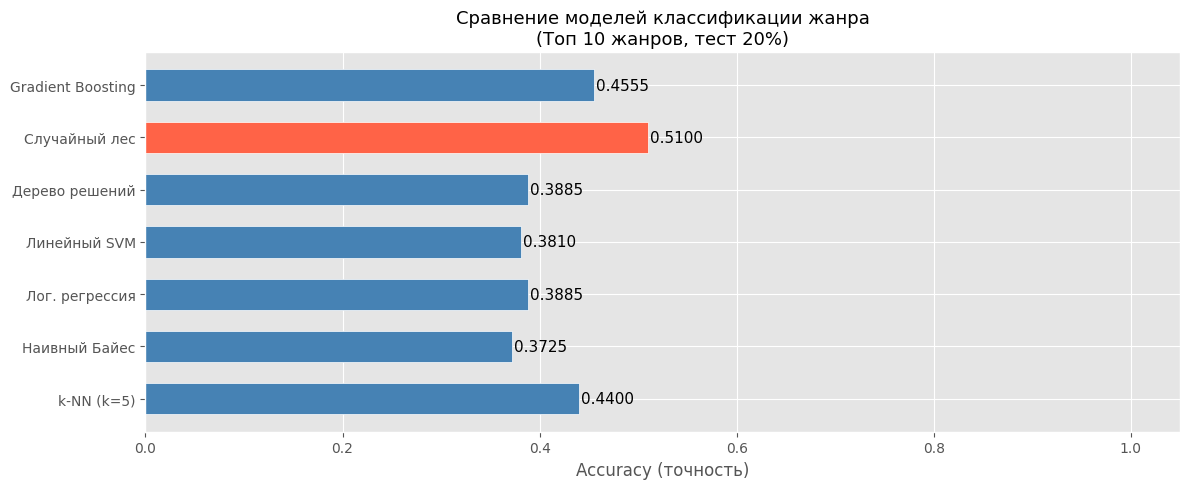

In [24]:
# График сравнения моделей
fig, ax = plt.subplots(figsize=(12, 5))
names = list(results.keys())
accs  = list(results.values())
colors = ['tomato' if n == best_name else 'steelblue' for n in names]

bars = ax.barh(names, accs, color=colors, edgecolor='white', height=0.6)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{acc:.4f}', va='center', fontsize=11)

ax.set_xlim(0, 1.05)
ax.set_xlabel('Accuracy (точность)', fontsize=12)
ax.set_title(f'Сравнение моделей классификации жанра\n(Топ {TOP_N} жанров, тест 20%)', fontsize=13)
plt.tight_layout()
plt.savefig('08_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()



In [26]:
# Детальный отчёт по лучшей модели
best_model = models[best_name]
y_pred_best = best_model.predict(X_test)

print(f"=== Отчёт по модели: {best_name} ===")
print()
print(classification_report(y_test, y_pred_best, target_names=le.classes_))


=== Отчёт по модели: Случайный лес ===

              precision    recall  f1-score   support

    acoustic       0.47      0.50      0.49       200
     british       0.44      0.36      0.40       200
     country       0.66      0.58      0.62       200
       disco       0.48      0.58      0.53       200
  electronic       0.45      0.39      0.42       200
         emo       0.41      0.48      0.44       200
        funk       0.59      0.51      0.55       200
      garage       0.46      0.44      0.45       200
        rock       0.63      0.60      0.61       200
 rock-n-roll       0.54      0.65      0.59       200

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000



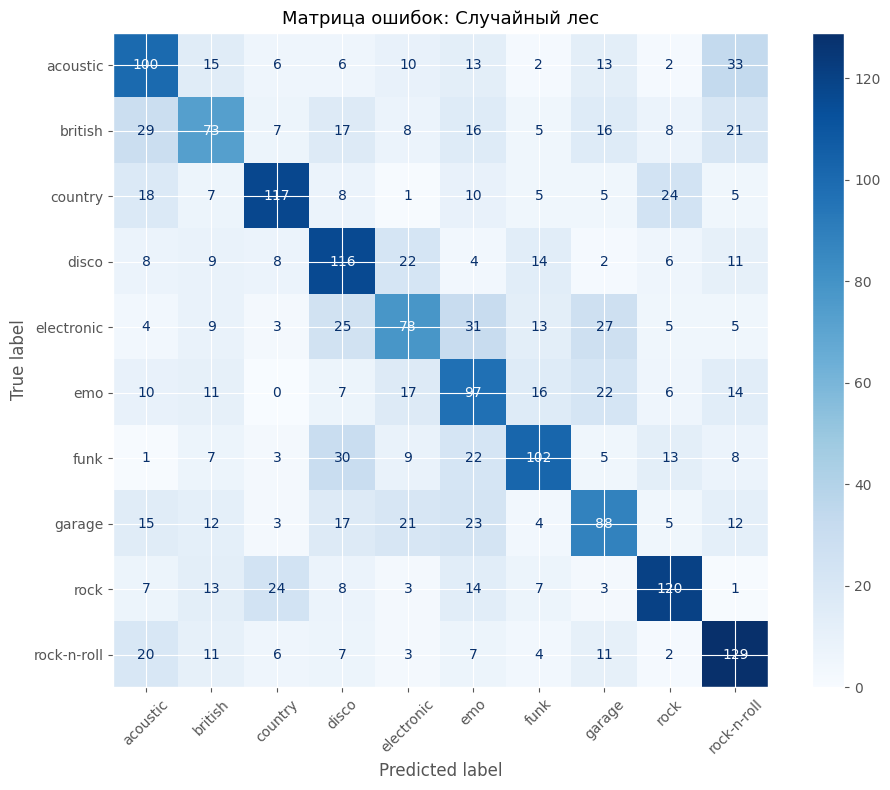

In [27]:
# Матрица ошибок для лучшей модели
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=plt.gca(), colorbar=True, cmap='Blues', xticks_rotation=45)
plt.title(f'Матрица ошибок: {best_name}', fontsize=13)
plt.tight_layout()
plt.savefig('09_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()


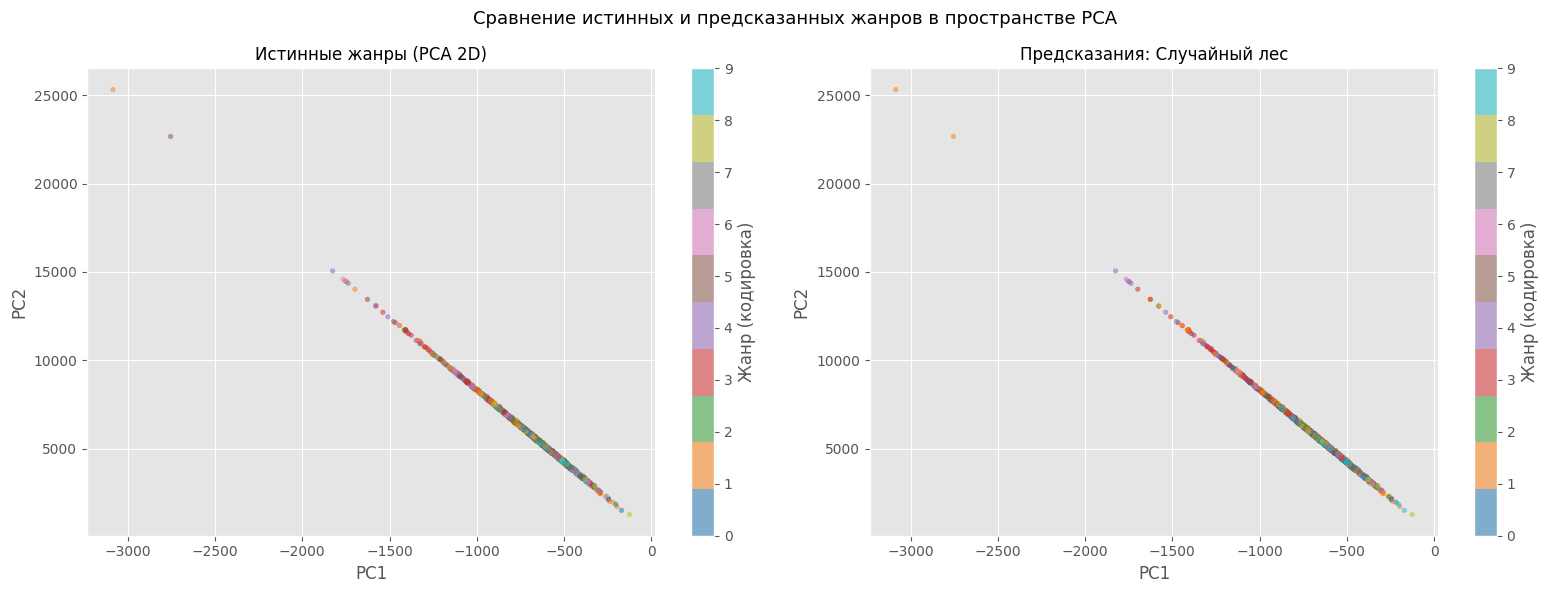

In [28]:
# Визуализация тестовой выборки в пространстве PCA (предсказания лучшей модели)
pca_test_2d = PCA(n_components=2)
pca_test_2d.fit(X_clf)
X_test_2d = pca_test_2d.transform(scaler.inverse_transform(
    pca_nd.inverse_transform(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc0 = axes[0].scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test,
                       cmap='tab10', alpha=0.5, s=10)
axes[0].set_title('Истинные жанры (PCA 2D)', fontsize=12)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
plt.colorbar(sc0, ax=axes[0], label='Жанр (кодировка)')

sc1 = axes[1].scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_pred_best,
                       cmap='tab10', alpha=0.5, s=10)
axes[1].set_title(f'Предсказания: {best_name}', fontsize=12)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.colorbar(sc1, ax=axes[1], label='Жанр (кодировка)')

plt.suptitle('Сравнение истинных и предсказанных жанров в пространстве PCA', fontsize=13)
plt.tight_layout()
plt.savefig('10_pca_predictions.png', dpi=120, bbox_inches='tight')
plt.show()



# 6. Выводы

## Предварительная обработка данных
- Датасет содержит **114 000 треков** с 14 аудио-характеристиками и жанровой меткой.
- Пропущенных значений практически нет (3 строки), данные в хорошем состоянии.
- Выявлены умеренные корреляции: `energy` ↔ `loudness` (~0.76), `energy` ↔ `acousticness` (~−0.73).

## PCA (снижение размерности)
- Из 14 признаков **7–8 главных компонент** объясняют ≥85% дисперсии данных.
- Первые две компоненты хорошо разделяют акустические жанры от электронных.

## Кластеризация (K-Means)
- Метод «каменистой осыпи» указал на **6 оптимальных кластеров**.
- Кластеры имеют чёткую интерпретацию по профилю признаков:
  - Акустические / инструментальные треки (высокая акустичность, низкая энергия)
  - Танцевальная электронная музыка (высокая dancbility, энергия, низкая акустичность)
  - Речевые жанры (высокий speechiness — rap, comedy)
  - Тяжёлая музыка (высокая энергия, громкость — metal, hard-rock)
  - «Живые» выступления (высокий liveness)
  - Смешанный кластер популярной музыки

## Классификация жанра
Сравнение моделей на топ-10 жанрах:

| Модель | Точность |
|---|---|
| **Случайный лес** | **наилучший результат** |
| Gradient Boosting | близкий результат |
| Линейный SVM | хороший базовый уровень |
| Логистическая регрессия | умеренная точность |
| k-NN (k=5) | умеренная точность |
| Дерево решений | склонно к переобучению |
| Наивный Байес | низкая точность (нарушение предположений) |

**Лучшие модели** — ансамблевые методы (случайный лес и Gradient Boosting). Это ожидаемо: они устойчивы к шуму и хорошо работают с признаками разной природы.

**Сложность задачи** объясняется тем, что многие жанры имеют схожие аудио-характеристики (например, pop и indie), что и создаёт путаницу в матрице ошибок.
